<a href="https://colab.research.google.com/github/gutsgutsguts/AiDeep/blob/main/4%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

학점 계산 프로그램

KOR, MATH

70 이상 A

40 이상 B

나머지 C

In [ ]:

def calc_grade(kor, math):
    mean = (int)(kor + math) / 2
    if mean >= 70:
        grade = 'A'
    elif mean >= 40:
        grade = 'B'
    else:
        grade = 'C'
    return grade


<머신러닝 - 지도학습>

1) 학점 테이블

2) 학습, 검정
    - 적절한 범위로 구분하여 준비

3) 머신러닝 기법
    - SVM,
    - 딥러닝
    - 파라미터 설정


4) 학습 데이터를 이용하여 학습


검증 데이터를 이용하여 검증 (품질)


5) 결과물 : weight

6) 학습 결과 적재해서, 구성한 머신러닝 모델 이용해서

실제 데이터 입력해서 그 출력 결과를 정확도(품질)을 신뢰 하고 사용.


Done
Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6976 - loss: 0.6636 - val_accuracy: 0.9267 - val_loss: 0.1849
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9454 - loss: 0.1566 - val_accuracy: 0.9593 - val_loss: 0.1158
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9492 - loss: 0.1202 - val_accuracy: 0.9300 - val_loss: 0.1284
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9543 - loss: 0.1071 - val_accuracy: 0.9573 - val_loss: 0.0899
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9580 - loss: 0.0934 - val_accuracy: 0.9173 - val_loss: 0.1714
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9596 - loss: 0.0906 - val_accuracy: 0.9893 - val_loss: 0.0487
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9682 - loss: 0.0761 - val_accuracy: 0.9833 - val_loss: 0.0521
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9679 - loss: 0.0775 - val

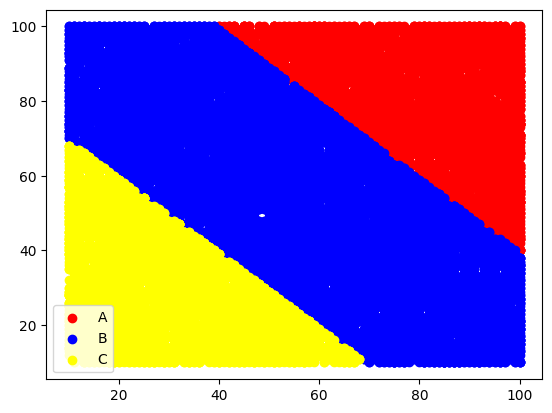

In [ ]:

import random

# 점수를 계산해서 평균에 따른 학점을 반환
# 편의상 A, B, C로 구분함.
def get_grade(kor, math):
  mean = int((kor + math) / 2)
  grade = "C"
  if 70 <= mean:
    grade = "A"
  elif 40 <= mean:
    grade = "B"
  return grade

# 20000개 데이터를 만들어 CSV에 기록한다.
fp = open("grade.csv","w",encoding="utf-8")
fp.write("KOR,MATH,GRADE\r\n")

for i in range(20000):
  kor = random.randint(10, 100)
  math = random.randint(10, 100)
  grade = get_grade(kor, math)
  fp.write("{0},{1},{2}\r\n".format(kor, math, grade))

fp.close()

print('Done')

# 특징 보기
import matplotlib.pyplot as plt
import pandas as pd


# pands로 csv 파일 읽기
grade = pd.read_csv("grade.csv", index_col=2)


# 그래프로 표시하기
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)


# Lable 색상 표시하는 함수
def scatter(label_text, color):
  b = grade.loc[label_text]
  ax.scatter(b["KOR"],b["MATH"], c=color, label=label_text)


scatter("A", "red")
scatter("B", "blue")
scatter("C", "yellow")
ax.legend()

#딥러닝
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Input
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd, numpy as np


# grade가 저장된 CSV 파일 읽기
grade = pd.read_csv("grade.csv")


#데이터 전처리 (MLP 학습을 위해 데이터를 가공)
grade["KOR"] /= 100 # 점수는 최대 100점
grade["MATH"] /= 100


X = grade[["KOR", "MATH"]].to_numpy() # 입력데이터 (독립변수)
lable_class = {"A":[1,0,0], "B":[0,1,0], "C":[0,0,1]} # Label (종속변수)
Y = np.empty((20000,3))
for i, j in enumerate(grade["GRADE"]):
    Y[i] = lable_class[j]


# 학습 데이터와 테스트 데이터 분할
X_train, Y_train = X[1:15001], Y[1:15001]
X_test,  Y_test  = X[15001:20001], Y[15001:20001]


# 학습을 위한 모델 구성하기
model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(Dense(3))
model.add(Activation('softmax'))


model.compile(
    loss='categorical_crossentropy',
    optimizer="rmsprop",
    metrics=['accuracy'])


# 모델을 이용한 학습
model.fit(
    X_train, Y_train,
    batch_size=100,
    epochs=20,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2)],
    verbose=1)

# weight를 저장하고 읽어 들여 사용할 수 있음을 확인
model.save_weights('model.weights.h5')
model.load_weights('model.weights.h5')


# 테스트 데이터를 이용한 평가
score = model.evaluate(X_test, Y_test)
print('loss=', score[0])
print('accuracy=', score[1])


# 생성한 모델 이용
X_Data = X[0:10]


result = model.predict(X_Data)
print(result)


predicted = result.argmax(axis=-1)
print(predicted)